In [ ]:
import os
from dataclasses import dataclass

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile as tiff

In [2]:
@dataclass
class BarProp:
    unique_bar_id: str
    height: int
    width: int

In [ ]:
date = "0529"
folder_0529 = f"images/{date}_original"
field_folders = [f for f in os.listdir(
    folder_0529) if os.path.isdir(os.path.join(folder_0529, f))]

bar_props = []

for field_folder in field_folders:
    bar_folders = [f for f in os.listdir(os.path.join(
        folder_0529, field_folder)) if os.path.isdir(os.path.join(folder_0529, field_folder, f))]
    for bar_folder in bar_folders:
        bar_folder_path = os.path.join(
            folder_0529, field_folder, bar_folder)
        images = os.listdir(bar_folder_path)
        if "label_map.tif" in images:
            aligned_image_path = f"{bar_folder_path}/aligned_image.tif"
            image = tiff.imread(aligned_image_path).mean(axis=-1)
            mask = (image > 0).astype(np.uint8) * 255
            eroded_mask = cv2.erode(
                mask, np.ones((3, 3), np.uint8), iterations=3
            )
            ys, xs = np.where(eroded_mask > 0)
            bar_props.append(
                BarProp(
                    unique_bar_id=f"{field_folder}_{bar_folder}",
                    height=ys.max() - ys.min(),
                    width=xs.max() - xs.min()
                )
            )
df_0529 = pd.DataFrame([bp.__dict__ for bp in bar_props])

In [ ]:
date = "0610"
folder_0610 = f"images/{date}_original"
field_folders = [f for f in os.listdir(
    folder_0610) if os.path.isdir(os.path.join(folder_0610, f))]

bar_props = []

for field_folder in field_folders:
    bar_folders = [f for f in os.listdir(os.path.join(
        folder_0610, field_folder)) if os.path.isdir(os.path.join(folder_0610, field_folder, f))]
    for bar_folder in bar_folders:
        bar_folder_path = os.path.join(
            folder_0610, field_folder, bar_folder)
        images = os.listdir(bar_folder_path)
        if "label_map.tif" in images:
            aligned_image_path = f"{bar_folder_path}/aligned_image.tif"
            image = tiff.imread(aligned_image_path).mean(axis=-1)
            mask = (image > 0).astype(np.uint8) * 255
            eroded_mask = cv2.erode(
                mask, np.ones((3, 3), np.uint8), iterations=3
            )
            ys, xs = np.where(eroded_mask > 0)
            bar_props.append(
                BarProp(
                    unique_bar_id=f"{field_folder}_{bar_folder}",
                    height=ys.max() - ys.min(),
                    width=xs.max() - xs.min()
                )
            )
df_0610 = pd.DataFrame([bp.__dict__ for bp in bar_props])

In [5]:
df_0529_filtered = pd.read_csv(
    "../output/0529_with_positions_correspondence.csv")
df_0610_filtered = pd.read_csv(
    "../output/0610_with_positions_correspondence.csv")

In [6]:
bar_prop_dict_0529 = {}
for row in df_0529.itertuples():
    bar_prop_dict_0529[row.unique_bar_id] = (row.height, row.width)

bar_prop_dict_0610 = {}
for row in df_0610.itertuples():
    bar_prop_dict_0610[row.unique_bar_id] = (row.height, row.width)

In [9]:
def set_height_width(row, bar_prop_dict):
    bar_unique_id = f"{row.field_name}_{row.bar_id}"
    row["height"] = bar_prop_dict.get(bar_unique_id, (np.nan, np.nan))[0]
    row["width"] = bar_prop_dict.get(bar_unique_id, (np.nan, np.nan))[1]
    return row


df_0529_filtered = df_0529_filtered.apply(
    set_height_width, axis=1, bar_prop_dict=bar_prop_dict_0529)
df_0610_filtered = df_0610_filtered.apply(
    set_height_width, axis=1, bar_prop_dict=bar_prop_dict_0610)

In [15]:
df_width_height_0529 = df_0529_filtered.loc[:, ["field_name", "bar_id", "height", "width"]][::5]
df_width_height_0610 = df_0610_filtered.loc[:, ["field_name", "bar_id", "height", "width"]][::5]

In [16]:
df_width_height_0529.to_csv("../output/height_width_0529_eroded.csv", index=False)
df_width_height_0610.to_csv("../output/height_width_0610_eroded.csv", index=False)

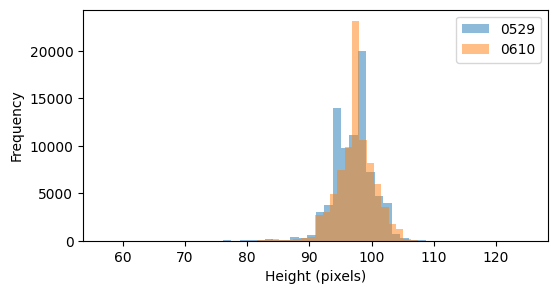

In [18]:
plt.figure(figsize=(6, 3))
plt.hist(df_0529_filtered["height"].dropna(), bins=50, alpha=0.5, label="0529")
plt.hist(df_0610_filtered["height"].dropna(), bins=50, alpha=0.5, label="0610")
plt.xlabel("Height (pixels)")
plt.ylabel("Frequency")
plt.legend()

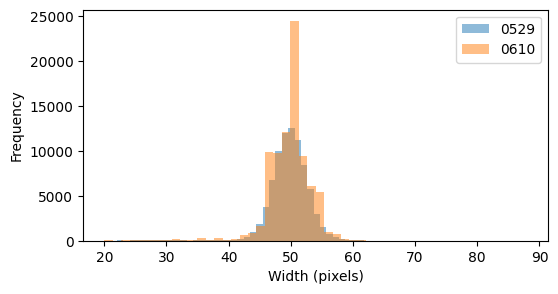

In [19]:
plt.figure(figsize=(6, 3))
plt.hist(df_0529_filtered["width"].dropna(), bins=50, alpha=0.5, label="0529")
plt.hist(df_0610_filtered["width"].dropna(), bins=50, alpha=0.5, label="0610")
plt.xlabel("Width (pixels)")
plt.ylabel("Frequency")
plt.legend()